# DP vs Non-DP Comparison Analysis

This notebook compares the performance of the DP (Dynamic Programming) optimized heuristic vs the non-DP version.

**Key metric**: For timeout cases (finished=False), **more expanded nodes = better** because it means the algorithm explored more of the search space before timing out.

In [107]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Set display options
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.0f}' if x > 1000 else f'{x:.4f}')

## 1. Load the Data

In [108]:
# Load DP results (full_test_1_1.csv)
dp_file = '2026-01-10_j30_g1-16_e1-10_all_full_test_1_1.csv'
df_dp = pd.read_csv(dp_file)
df_dp['version'] = 'DP'

# Load non-DP results
no_dp_file = 'test_no_dp_1-16_e1-10_12_1_2026.csv'
df_no_dp = pd.read_csv(no_dp_file)
df_no_dp['version'] = 'No-DP'

print(f"DP file rows: {len(df_dp)}")
print(f"Non-DP file rows: {len(df_no_dp)}")

DP file rows: 320
Non-DP file rows: 320


## 2. Filter for TP Method + Timeout Cases Only

In [109]:
# Filter: TP method only, finished=False (timeout cases)
dp_tp_timeout = df_dp[(df_dp['PetriType'] == 'TP') & (df_dp['finished'] == False)].copy()
no_dp_tp_timeout = df_no_dp[(df_no_dp['PetriType'] == 'TP') & (df_no_dp['finished'] == False)].copy()

print(f"DP timeout cases: {len(dp_tp_timeout)}")
print(f"Non-DP timeout cases: {len(no_dp_tp_timeout)}")

DP timeout cases: 86
Non-DP timeout cases: 87


## 3. Merge and Compare

In [110]:
# Create problem ID for merging
dp_tp_timeout['problem_id'] = dp_tp_timeout['group'].astype(str) + ':' + dp_tp_timeout['exam'].astype(str)
no_dp_tp_timeout['problem_id'] = no_dp_tp_timeout['group'].astype(str) + ':' + no_dp_tp_timeout['exam'].astype(str)

# Select relevant columns
dp_subset = dp_tp_timeout[['problem_id', 'group', 'exam', 'expand_number', 'time']].copy()
dp_subset.columns = ['problem_id', 'group', 'exam', 'dp_nodes', 'dp_time']

no_dp_subset = no_dp_tp_timeout[['problem_id', 'expand_number', 'time']].copy()
no_dp_subset.columns = ['problem_id', 'no_dp_nodes', 'no_dp_time']

# Merge on problem_id
comparison = pd.merge(dp_subset, no_dp_subset, on='problem_id', how='inner')

print(f"Matched timeout cases: {len(comparison)}")

Matched timeout cases: 85


## 4. Calculate Differences and Winner

In [111]:
# Calculate difference and percentage improvement
comparison['node_diff'] = comparison['dp_nodes'] - comparison['no_dp_nodes']
comparison['dp_improvement_pct'] = ((comparison['dp_nodes'] - comparison['no_dp_nodes']) / comparison['no_dp_nodes'] * 100).round(2)

# Determine winner (more nodes = better for timeout cases)
def determine_winner(row):
    if row['dp_nodes'] > row['no_dp_nodes']:
        return 'DP'
    elif row['dp_nodes'] < row['no_dp_nodes']:
        return 'No-DP'
    else:
        return 'Tie'

comparison['winner'] = comparison.apply(determine_winner, axis=1)

# Sort by group and exam
comparison = comparison.sort_values(['group', 'exam'])

print(comparison[['problem_id', 'dp_nodes', 'no_dp_nodes', 'node_diff', 'dp_improvement_pct', 'winner']].to_string())

   problem_id  dp_nodes  no_dp_nodes  node_diff  dp_improvement_pct winner
0         1:1  29933442     15058571   14874871             98.7800     DP
1         1:2  30810486     19735065   11075421             56.1200     DP
2         1:3  36564060     19905044   16659016             83.6900     DP
3         1:4  23400515     18361419    5039096             27.4400     DP
4         1:5  18692766     17868182     824584              4.6100     DP
5         1:6  22357392     23751509   -1394117             -5.8700  No-DP
6         1:8  30652702     21511781    9140921             42.4900     DP
7         1:9  21570214     18886955    2683259             14.2100     DP
8        1:10  26353699     20364885    5988814             29.4100     DP
9         2:1  19919078     20334031    -414953             -2.0400  No-DP
10        2:2  25570551     20745424    4825127             23.2600     DP
11        2:4  29588303     21872728    7715575             35.2700     DP
12        2:6  27164757  

## 5. Summary Statistics

In [112]:
# Count wins
win_counts = comparison['winner'].value_counts()
total_cases = len(comparison)

print("="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"\nTotal timeout cases compared: {total_cases}")
print(f"\nWinner Distribution:")
for winner, count in win_counts.items():
    pct = count / total_cases * 100
    print(f"  {winner}: {count} cases ({pct:.1f}%)")

# Calculate averages
print(f"\nAverage Nodes Expanded:")
print(f"  DP:    {comparison['dp_nodes'].mean():,.0f}")
print(f"  No-DP: {comparison['no_dp_nodes'].mean():,.0f}")
print(f"  Difference: {comparison['node_diff'].mean():+,.0f}")

# Calculate median improvement
print(f"\nDP Improvement Statistics:")
print(f"  Mean improvement: {comparison['dp_improvement_pct'].mean():+.1f}%")
print(f"  Median improvement: {comparison['dp_improvement_pct'].median():+.1f}%")
print(f"  Max improvement: {comparison['dp_improvement_pct'].max():+.1f}%")
print(f"  Min improvement: {comparison['dp_improvement_pct'].min():+.1f}%")

SUMMARY STATISTICS

Total timeout cases compared: 85

Winner Distribution:
  DP: 59 cases (69.4%)
  No-DP: 25 cases (29.4%)
  Tie: 1 cases (1.2%)

Average Nodes Expanded:
  DP:    16,193,120
  No-DP: 13,092,943
  Difference: +3,100,177

DP Improvement Statistics:
  Mean improvement: +54.8%
  Median improvement: +27.0%
  Max improvement: +711.6%
  Min improvement: -86.0%


## 6. Cases Where DP Wins

In [113]:
dp_wins = comparison[comparison['winner'] == 'DP'].copy()
dp_wins_sorted = dp_wins.sort_values('dp_improvement_pct', ascending=False)

print(f"\nDP WINS ({len(dp_wins)} cases):")
print("="*80)
print(dp_wins_sorted[['problem_id', 'dp_nodes', 'no_dp_nodes', 'node_diff', 'dp_improvement_pct']].to_string())


DP WINS (59 cases):
   problem_id  dp_nodes  no_dp_nodes  node_diff  dp_improvement_pct
41        7:7  25583123      3152051   22431072            711.6300
22        5:2  16844965      2412075   14432890            598.3600
56       10:2  22569937      3943544   18626393            472.3300
68       13:2   9082201      1807899    7274302            402.3600
64       11:5  16704947      3379673   13325274            394.2800
65       11:7  23545146      8481164   15063982            177.6200
18        3:9  24332011      8831384   15500627            175.5200
42        7:8  26477572      9744594   16732978            171.7200
26        5:6  23661659      9277442   14384217            155.0500
63       11:4  23512841     10099024   13413817            132.8200
55       10:1  27303522     12325371   14978151            121.5200
12        2:6  27164757     12316764   14847993            120.5500
45        9:1   3252827      1610102    1642725            102.0300
0         1:1  29933442    

## 7. Cases Where Non-DP Wins

In [114]:
no_dp_wins = comparison[comparison['winner'] == 'No-DP'].copy()
no_dp_wins_sorted = no_dp_wins.sort_values('dp_improvement_pct', ascending=True)

print(f"\nNON-DP WINS ({len(no_dp_wins)} cases):")
print("="*80)
if len(no_dp_wins) > 0:
    print(no_dp_wins_sorted[['problem_id', 'dp_nodes', 'no_dp_nodes', 'node_diff', 'dp_improvement_pct']].to_string())
else:
    print("No cases where Non-DP wins!")


NON-DP WINS (25 cases):
   problem_id  dp_nodes  no_dp_nodes  node_diff  dp_improvement_pct
79       14:3    281259      2011274   -1730015            -86.0200
69       13:3   1383018      6992521   -5609503            -80.2200
61       10:8   6006906     23146913  -17140007            -74.0500
21        5:1   5413749     16049399  -10635650            -66.2700
33        6:3   6575929     18271704  -11695775            -64.0100
66       11:8   3310162      6954193   -3644031            -52.4000
54       9:10   9123682     18693745   -9570063            -51.1900
83      14:10  14152337     28989362  -14837025            -51.1800
34        6:4   8789533     17950838   -9161305            -51.0400
15       2:10   9086926     18157971   -9071045            -49.9600
35        6:5  10351709     19990187   -9638478            -48.2200
30       5:10   4943212      9344833   -4401621            -47.1000
24        5:4  10378989     17847255   -7468266            -41.8500
60       10:6   7686581

## 8. Tie Cases

In [115]:
ties = comparison[comparison['winner'] == 'Tie'].copy()

print(f"\nTIE CASES ({len(ties)} cases):")
print("="*80)
if len(ties) > 0:
    print(ties[['problem_id', 'dp_nodes', 'no_dp_nodes']].to_string())
else:
    print("No tie cases!")


TIE CASES (1 cases):
   problem_id  dp_nodes  no_dp_nodes
20        4:9  20430551     20430551


## 9. Visualization: Node Comparison

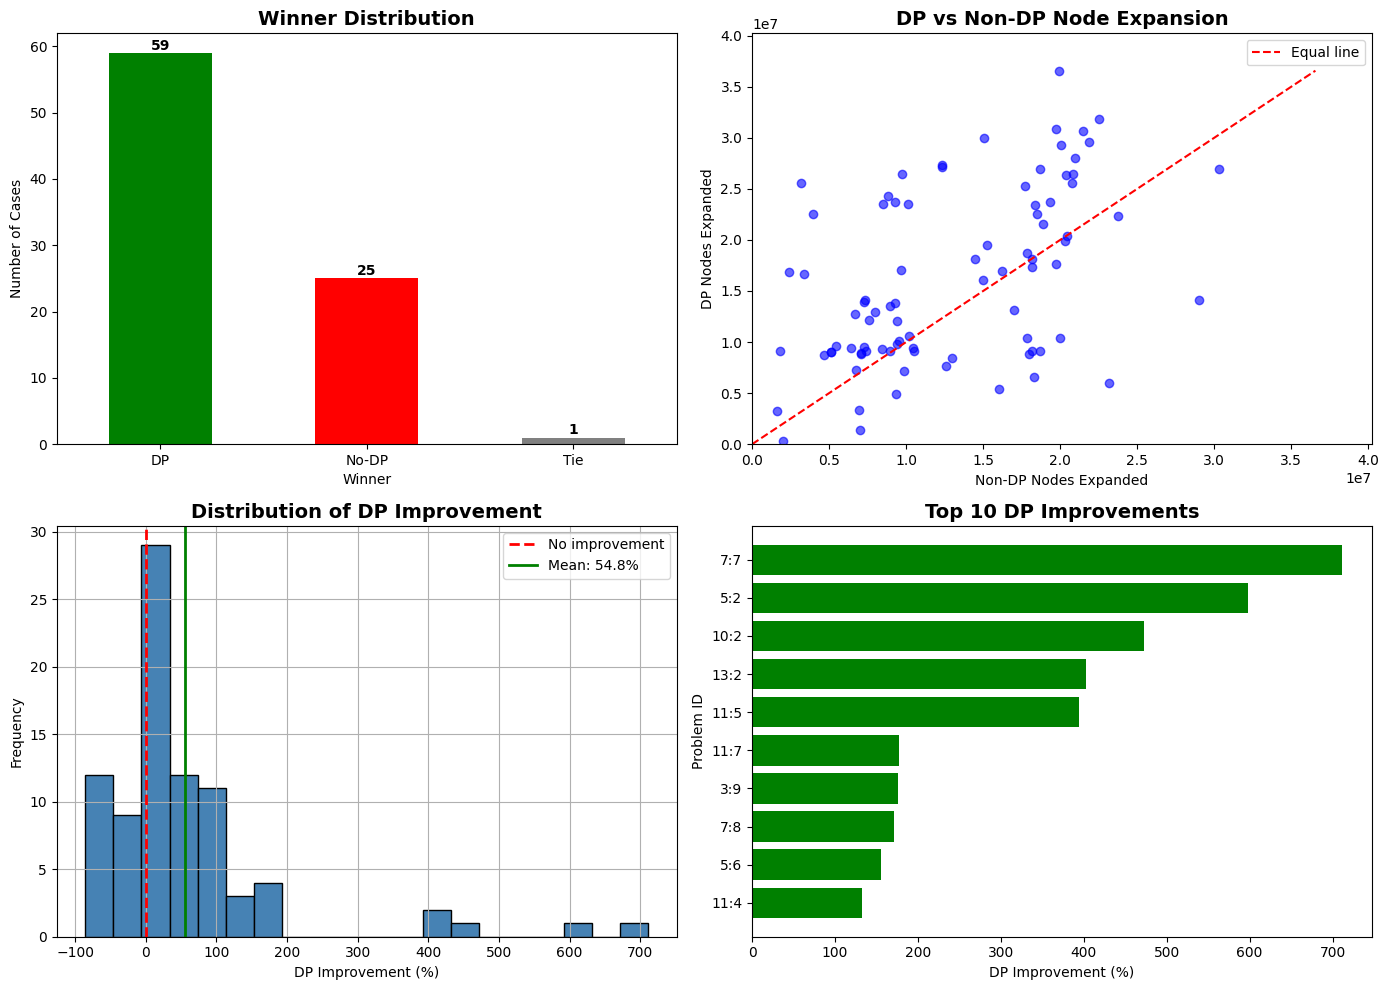


Chart saved as 'dp_vs_no_dp_comparison.png'


In [116]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Bar chart of winner counts
ax1 = axes[0, 0]
colors = {'DP': 'green', 'No-DP': 'red', 'Tie': 'gray'}
win_counts.plot(kind='bar', ax=ax1, color=[colors.get(x, 'blue') for x in win_counts.index])
ax1.set_title('Winner Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Winner')
ax1.set_ylabel('Number of Cases')
ax1.tick_params(axis='x', rotation=0)
for i, v in enumerate(win_counts.values):
    ax1.text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# Plot 2: Scatter plot DP vs Non-DP nodes
ax2 = axes[0, 1]
max_val = max(comparison['dp_nodes'].max(), comparison['no_dp_nodes'].max())
ax2.scatter(comparison['no_dp_nodes'], comparison['dp_nodes'], alpha=0.6, c='blue')
ax2.plot([0, max_val], [0, max_val], 'r--', label='Equal line')
ax2.set_xlabel('Non-DP Nodes Expanded')
ax2.set_ylabel('DP Nodes Expanded')
ax2.set_title('DP vs Non-DP Node Expansion', fontsize=14, fontweight='bold')
ax2.legend()
ax2.set_xlim(0, max_val * 1.1)
ax2.set_ylim(0, max_val * 1.1)

# Plot 3: Histogram of improvement percentages
ax3 = axes[1, 0]
comparison['dp_improvement_pct'].hist(bins=20, ax=ax3, color='steelblue', edgecolor='black')
ax3.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No improvement')
ax3.axvline(x=comparison['dp_improvement_pct'].mean(), color='green', linestyle='-', linewidth=2, label=f'Mean: {comparison["dp_improvement_pct"].mean():.1f}%')
ax3.set_xlabel('DP Improvement (%)')
ax3.set_ylabel('Frequency')
ax3.set_title('Distribution of DP Improvement', fontsize=14, fontweight='bold')
ax3.legend()

# Plot 4: Top 10 biggest DP wins
ax4 = axes[1, 1]
top_10 = comparison.nlargest(10, 'dp_improvement_pct')
bars = ax4.barh(top_10['problem_id'], top_10['dp_improvement_pct'], color='green')
ax4.set_xlabel('DP Improvement (%)')
ax4.set_ylabel('Problem ID')
ax4.set_title('Top 10 DP Improvements', fontsize=14, fontweight='bold')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('dp_vs_no_dp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nChart saved as 'dp_vs_no_dp_comparison.png'")

## 10. Final Conclusion

In [117]:
dp_win_rate = (win_counts.get('DP', 0) / total_cases * 100) if 'DP' in win_counts else 0
no_dp_win_rate = (win_counts.get('No-DP', 0) / total_cases * 100) if 'No-DP' in win_counts else 0
tie_rate = (win_counts.get('Tie', 0) / total_cases * 100) if 'Tie' in win_counts else 0

print("="*70)
print("FINAL CONCLUSION")
print("="*70)
print(f"")
print(f"📊 Analysis of {total_cases} TP timeout cases:")
print(f"")
print(f"   ✅ DP wins:     {win_counts.get('DP', 0):3d} cases ({dp_win_rate:.1f}%)")
print(f"   ❌ No-DP wins:  {win_counts.get('No-DP', 0):3d} cases ({no_dp_win_rate:.1f}%)")
print(f"   ⚪ Ties:        {win_counts.get('Tie', 0):3d} cases ({tie_rate:.1f}%)")
print(f"")
print(f"📈 Performance Metrics:")
print(f"   • Average DP improvement: {comparison['dp_improvement_pct'].mean():+.1f}%")
print(f"   • DP explores {comparison['dp_nodes'].mean() / comparison['no_dp_nodes'].mean():.2f}x more nodes on average")
print(f"")

if dp_win_rate > 60:
    print(f"🎯 VERDICT: DP optimization is SIGNIFICANTLY BETTER!")
    print(f"   The DP version explores more nodes in {dp_win_rate:.0f}% of timeout cases,")
    print(f"   giving it a better chance of finding optimal solutions.")
elif dp_win_rate > 50:
    print(f"🎯 VERDICT: DP optimization is moderately better.")
else:
    print(f"🎯 VERDICT: Results are mixed - more investigation needed.")

print("="*70)

FINAL CONCLUSION

📊 Analysis of 85 TP timeout cases:

   ✅ DP wins:      59 cases (69.4%)
   ❌ No-DP wins:   25 cases (29.4%)
   ⚪ Ties:          1 cases (1.2%)

📈 Performance Metrics:
   • Average DP improvement: +54.8%
   • DP explores 1.24x more nodes on average

🎯 VERDICT: DP optimization is SIGNIFICANTLY BETTER!
   The DP version explores more nodes in 69% of timeout cases,
   giving it a better chance of finding optimal solutions.


## 11. Export Detailed Results

In [118]:
# Export comparison results to CSV
output_file = 'dp_vs_no_dp_comparison_results.csv'
comparison.to_csv(output_file, index=False)
print(f"Detailed results exported to: {output_file}")

# Display the full comparison table
print("\n" + "="*100)
print("FULL COMPARISON TABLE")
print("="*100)
display_cols = ['problem_id', 'dp_nodes', 'no_dp_nodes', 'node_diff', 'dp_improvement_pct', 'winner']
print(comparison[display_cols].to_string())

Detailed results exported to: dp_vs_no_dp_comparison_results.csv

FULL COMPARISON TABLE
   problem_id  dp_nodes  no_dp_nodes  node_diff  dp_improvement_pct winner
0         1:1  29933442     15058571   14874871             98.7800     DP
1         1:2  30810486     19735065   11075421             56.1200     DP
2         1:3  36564060     19905044   16659016             83.6900     DP
3         1:4  23400515     18361419    5039096             27.4400     DP
4         1:5  18692766     17868182     824584              4.6100     DP
5         1:6  22357392     23751509   -1394117             -5.8700  No-DP
6         1:8  30652702     21511781    9140921             42.4900     DP
7         1:9  21570214     18886955    2683259             14.2100     DP
8        1:10  26353699     20364885    5988814             29.4100     DP
9         2:1  19919078     20334031    -414953             -2.0400  No-DP
10        2:2  25570551     20745424    4825127             23.2600     DP
11        2:

## 12. TT Method Timeout Comparison

Now let's compare the TT (Time-based Transitions) method for timeout cases (finished=False).

In [119]:
# Filter: TT method only, finished=False (timeout cases)
dp_tt_timeout = df_dp[(df_dp['PetriType'] == 'TT') & (df_dp['finished'] == False)].copy()
no_dp_tt_timeout = df_no_dp[(df_no_dp['PetriType'] == 'TT') & (df_no_dp['finished'] == False)].copy()

print(f"DP TT timeout cases: {len(dp_tt_timeout)}")
print(f"Non-DP TT timeout cases: {len(no_dp_tt_timeout)}")

# Create problem ID for merging
dp_tt_timeout['problem_id'] = dp_tt_timeout['group'].astype(str) + ':' + dp_tt_timeout['exam'].astype(str)
no_dp_tt_timeout['problem_id'] = no_dp_tt_timeout['group'].astype(str) + ':' + no_dp_tt_timeout['exam'].astype(str)

# Select relevant columns
dp_tt_subset = dp_tt_timeout[['problem_id', 'group', 'exam', 'expand_number', 'time']].copy()
dp_tt_subset.columns = ['problem_id', 'group', 'exam', 'dp_nodes', 'dp_time']

no_dp_tt_subset = no_dp_tt_timeout[['problem_id', 'expand_number', 'time']].copy()
no_dp_tt_subset.columns = ['problem_id', 'no_dp_nodes', 'no_dp_time']

# Merge on problem_id
tt_comparison = pd.merge(dp_tt_subset, no_dp_tt_subset, on='problem_id', how='inner')

print(f"Matched TT timeout cases: {len(tt_comparison)}")

DP TT timeout cases: 34
Non-DP TT timeout cases: 35
Matched TT timeout cases: 34


In [120]:
# Compare nodes expanded - more is better for timeout cases
tt_comparison['node_diff'] = tt_comparison['dp_nodes'] - tt_comparison['no_dp_nodes']
tt_comparison['node_diff_pct'] = (tt_comparison['node_diff'] / tt_comparison['no_dp_nodes'] * 100).round(2)
tt_comparison['winner'] = tt_comparison['node_diff'].apply(lambda x: 'DP' if x > 0 else ('Non-DP' if x < 0 else 'Tie'))

# Display results
print("TT Timeout Comparison (more nodes = better for timeouts):")
print("=" * 60)
print(tt_comparison[['problem_id', 'dp_nodes', 'no_dp_nodes', 'node_diff', 'node_diff_pct', 'winner']].to_string())

# Summary statistics
print("\n" + "=" * 60)
print("Winner Summary (TT):")
print(tt_comparison['winner'].value_counts())

dp_wins_tt = (tt_comparison['winner'] == 'DP').sum()
no_dp_wins_tt = (tt_comparison['winner'] == 'Non-DP').sum()
ties_tt = (tt_comparison['winner'] == 'Tie').sum()
total_tt = len(tt_comparison)

print(f"\nDP wins: {dp_wins_tt}/{total_tt} ({dp_wins_tt/total_tt*100:.1f}%)")
print(f"Non-DP wins: {no_dp_wins_tt}/{total_tt} ({no_dp_wins_tt/total_tt*100:.1f}%)")
print(f"Ties: {ties_tt}/{total_tt} ({ties_tt/total_tt*100:.1f}%)")

TT Timeout Comparison (more nodes = better for timeouts):
   problem_id  dp_nodes  no_dp_nodes  node_diff  node_diff_pct  winner
0         5:2   6434007      1829528    4604479       251.6800      DP
1         5:3    926997      5502737   -4575740       -83.1500  Non-DP
2         5:5   7254320      4631194    2623126        56.6400      DP
3         5:7   4615986      3833052     782934        20.4300      DP
4         5:8   5794030       524480    5269550          1,005      DP
5         5:9   5897671      2302519    3595152       156.1400      DP
6        5:10   6038886      1445287    4593599       317.8300      DP
7         7:9   3019862      3798576    -778714       -20.5000  Non-DP
8         9:1   1669305      1047280     622025        59.3900      DP
9         9:2   2157350      1165644     991706        85.0800      DP
10        9:3   2341665      1101168    1240497       112.6500      DP
11        9:4   2501408      1402011    1099397        78.4200      DP
12        9:5   177

TT Node Difference Statistics (positive = DP explored more):
Mean node difference: 844,337
Median node difference: 572,574
Min node difference: -4,575,740
Max node difference: 5,269,550

Mean percentage difference: 390.7%


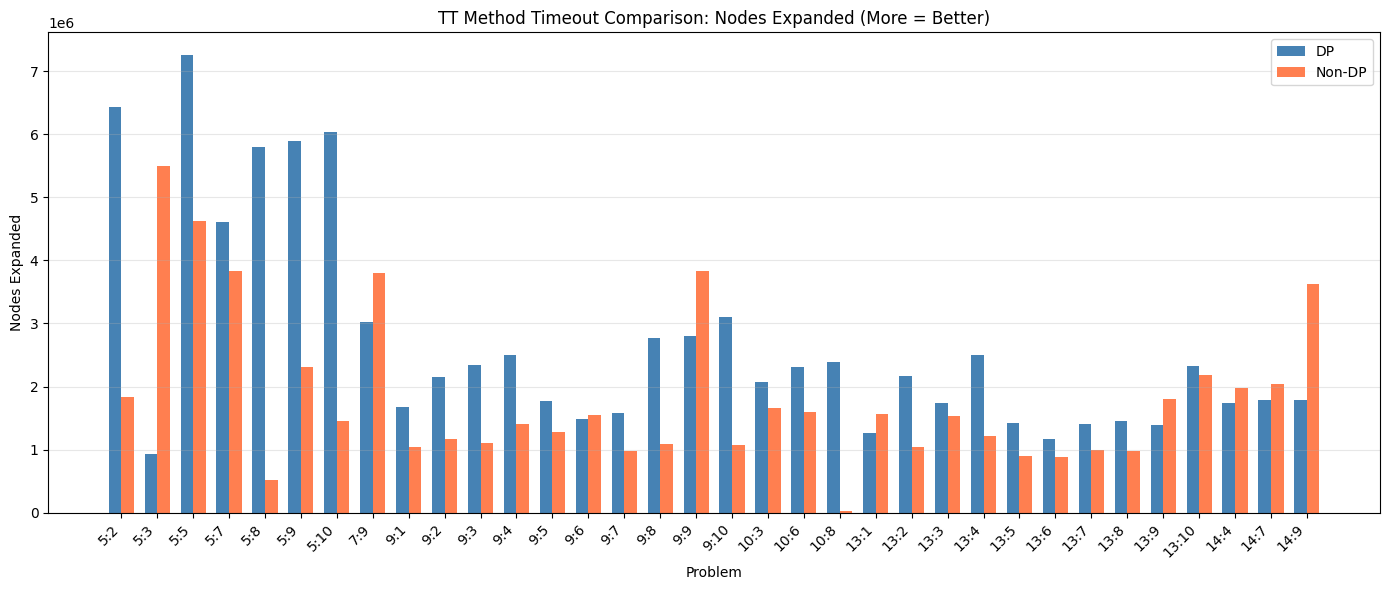

In [121]:
# Statistics on node difference (TT)
print("TT Node Difference Statistics (positive = DP explored more):")
print("=" * 60)
print(f"Mean node difference: {tt_comparison['node_diff'].mean():,.0f}")
print(f"Median node difference: {tt_comparison['node_diff'].median():,.0f}")
print(f"Min node difference: {tt_comparison['node_diff'].min():,.0f}")
print(f"Max node difference: {tt_comparison['node_diff'].max():,.0f}")
print(f"\nMean percentage difference: {tt_comparison['node_diff_pct'].mean():.1f}%")

# Bar chart comparing TT nodes
fig, ax = plt.subplots(figsize=(14, 6))
x = range(len(tt_comparison))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], tt_comparison['dp_nodes'], width, label='DP', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], tt_comparison['no_dp_nodes'], width, label='Non-DP', color='coral')

ax.set_xlabel('Problem')
ax.set_ylabel('Nodes Expanded')
ax.set_title('TT Method Timeout Comparison: Nodes Expanded (More = Better)')
ax.set_xticks(x)
ax.set_xticklabels(tt_comparison['problem_id'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 13. Combined TP + TT Timeout Summary

In [122]:
# Combined summary
print("=" * 60)
print("COMBINED TIMEOUT SUMMARY (TP + TT)")
print("=" * 60)

# Add method column (comparison is the TP data)
tp_comparison = comparison.copy()
tp_comparison['method'] = 'TP'
tt_comparison['method'] = 'TT'

# Combine both
combined = pd.concat([tp_comparison, tt_comparison], ignore_index=True)

print(f"\nTotal timeout cases analyzed: {len(combined)}")
print(f"  - TP cases: {len(tp_comparison)}")
print(f"  - TT cases: {len(tt_comparison)}")

print("\n" + "-" * 40)
print("Overall Winner Summary:")
print(combined['winner'].value_counts())

total_dp_wins = (combined['winner'] == 'DP').sum()
total_no_dp_wins = (combined['winner'] == 'Non-DP').sum()
total_ties = (combined['winner'] == 'Tie').sum()
total = len(combined)

print(f"\nDP wins: {total_dp_wins}/{total} ({total_dp_wins/total*100:.1f}%)")
print(f"Non-DP wins: {total_no_dp_wins}/{total} ({total_no_dp_wins/total*100:.1f}%)")
print(f"Ties: {total_ties}/{total} ({total_ties/total*100:.1f}%)")

print("\n" + "-" * 40)
print("By Method:")
for method in ['TP', 'TT']:
    subset = combined[combined['method'] == method]
    dp_wins = (subset['winner'] == 'DP').sum()
    n = len(subset)
    avg_diff_pct = subset['node_diff_pct'].mean()
    print(f"{method}: DP wins {dp_wins}/{n} ({dp_wins/n*100:.1f}%), avg diff: {avg_diff_pct:+.1f}%")

COMBINED TIMEOUT SUMMARY (TP + TT)

Total timeout cases analyzed: 119
  - TP cases: 85
  - TT cases: 34

----------------------------------------
Overall Winner Summary:
winner
DP        84
No-DP     25
Non-DP     9
Tie        1
Name: count, dtype: int64

DP wins: 84/119 (70.6%)
Non-DP wins: 9/119 (7.6%)
Ties: 1/119 (0.8%)

----------------------------------------
By Method:
TP: DP wins 59/85 (69.4%), avg diff: +nan%
TT: DP wins 25/34 (73.5%), avg diff: +390.7%


## 14. Cases Where DP Solves but Non-DP Times Out

Analyzing cases where:
- DP: finished=True (successfully solved)
- Non-DP: finished=False (timed out)

This shows problems that DP can solve but Non-DP cannot within the time limit.

In [123]:
# TP Method: DP finished=True, Non-DP finished=False
dp_tp_solved = df_dp[(df_dp['PetriType'] == 'TP') & (df_dp['finished'] == True)].copy()
no_dp_tp_timeout_all = df_no_dp[(df_no_dp['PetriType'] == 'TP') & (df_no_dp['finished'] == False)].copy()

# Create problem IDs
dp_tp_solved['problem_id'] = dp_tp_solved['group'].astype(str) + ':' + dp_tp_solved['exam'].astype(str)
no_dp_tp_timeout_all['problem_id'] = no_dp_tp_timeout_all['group'].astype(str) + ':' + no_dp_tp_timeout_all['exam'].astype(str)

# Find intersection: problems DP solved but Non-DP timed out
dp_solved_no_dp_timeout_tp = pd.merge(
    dp_tp_solved[['problem_id', 'group', 'exam', 'expand_number', 'time', 'makespan']],
    no_dp_tp_timeout_all[['problem_id', 'expand_number', 'time']],
    on='problem_id',
    suffixes=('_dp', '_no_dp')
)

print("=" * 70)
print("TP METHOD: DP Solved but Non-DP Timed Out")
print("=" * 70)
print(f"\nTotal cases where DP solved but Non-DP timed out: {len(dp_solved_no_dp_timeout_tp)}")

if len(dp_solved_no_dp_timeout_tp) > 0:
    print("\nDetailed Results:")
    print(dp_solved_no_dp_timeout_tp[['problem_id', 'makespan', 'expand_number_dp', 'time_dp', 'expand_number_no_dp', 'time_no_dp']].to_string())
    
    print(f"\n📊 DP Statistics for these solved cases:")
    print(f"   Average nodes expanded: {dp_solved_no_dp_timeout_tp['expand_number_dp'].mean():,.0f}")
    print(f"   Average time: {dp_solved_no_dp_timeout_tp['time_dp'].mean():.2f}s")
    print(f"   Average makespan: {dp_solved_no_dp_timeout_tp['makespan'].mean():.1f}")
else:
    print("\n✅ No cases found - Non-DP solved all problems that DP solved!")

TP METHOD: DP Solved but Non-DP Timed Out

Total cases where DP solved but Non-DP timed out: 2

Detailed Results:
  problem_id  makespan  expand_number_dp  time_dp  expand_number_no_dp  time_no_dp
0        7:6        35          25670517 291.8910             15092687       1,101
1       10:7        49          15933709  76.3357              8273933       1,067

📊 DP Statistics for these solved cases:
   Average nodes expanded: 20,802,113
   Average time: 184.11s
   Average makespan: 42.0


In [124]:
# TT Method: DP finished=True, Non-DP finished=False
dp_tt_solved = df_dp[(df_dp['PetriType'] == 'TT') & (df_dp['finished'] == True)].copy()
no_dp_tt_timeout_all = df_no_dp[(df_no_dp['PetriType'] == 'TT') & (df_no_dp['finished'] == False)].copy()

# Create problem IDs
dp_tt_solved['problem_id'] = dp_tt_solved['group'].astype(str) + ':' + dp_tt_solved['exam'].astype(str)
no_dp_tt_timeout_all['problem_id'] = no_dp_tt_timeout_all['group'].astype(str) + ':' + no_dp_tt_timeout_all['exam'].astype(str)

# Find intersection: problems DP solved but Non-DP timed out
dp_solved_no_dp_timeout_tt = pd.merge(
    dp_tt_solved[['problem_id', 'group', 'exam', 'expand_number', 'time', 'makespan']],
    no_dp_tt_timeout_all[['problem_id', 'expand_number', 'time']],
    on='problem_id',
    suffixes=('_dp', '_no_dp')
)

print("=" * 70)
print("TT METHOD: DP Solved but Non-DP Timed Out")
print("=" * 70)
print(f"\nTotal cases where DP solved but Non-DP timed out: {len(dp_solved_no_dp_timeout_tt)}")

if len(dp_solved_no_dp_timeout_tt) > 0:
    print("\nDetailed Results:")
    print(dp_solved_no_dp_timeout_tt[['problem_id', 'makespan', 'expand_number_dp', 'time_dp', 'expand_number_no_dp', 'time_no_dp']].to_string())
    
    print(f"\n📊 DP Statistics for these solved cases:")
    print(f"   Average nodes expanded: {dp_solved_no_dp_timeout_tt['expand_number_dp'].mean():,.0f}")
    print(f"   Average time: {dp_solved_no_dp_timeout_tt['time_dp'].mean():.2f}s")
    print(f"   Average makespan: {dp_solved_no_dp_timeout_tt['makespan'].mean():.1f}")
else:
    print("\n✅ No cases found - Non-DP solved all problems that DP solved!")

TT METHOD: DP Solved but Non-DP Timed Out

Total cases where DP solved but Non-DP timed out: 1

Detailed Results:
  problem_id  makespan  expand_number_dp  time_dp  expand_number_no_dp  time_no_dp
0       14:1        50           2759693  34.0107              2211642    468.1770

📊 DP Statistics for these solved cases:
   Average nodes expanded: 2,759,693
   Average time: 34.01s
   Average makespan: 50.0


In [125]:
# Combined summary: DP solves but Non-DP doesn't
print("\n" + "=" * 70)
print("COMBINED SUMMARY: DP SOLVES BUT NON-DP TIMES OUT")
print("=" * 70)

total_dp_advantage = len(dp_solved_no_dp_timeout_tp) + len(dp_solved_no_dp_timeout_tt)

print(f"\nTotal problems DP solved but Non-DP timed out: {total_dp_advantage}")
print(f"  - TP method: {len(dp_solved_no_dp_timeout_tp)} problems")
print(f"  - TT method: {len(dp_solved_no_dp_timeout_tt)} problems")

if total_dp_advantage > 0:
    print("\n🎯 KEY INSIGHT:")
    print(f"   DP successfully solved {total_dp_advantage} problems that Non-DP could not!")
    print(f"   This demonstrates clear algorithmic advantage of the DP optimization.")
    
    # Combine both for overall statistics
    if len(dp_solved_no_dp_timeout_tp) > 0 and len(dp_solved_no_dp_timeout_tt) > 0:
        combined_solved = pd.concat([
            dp_solved_no_dp_timeout_tp.assign(method='TP'),
            dp_solved_no_dp_timeout_tt.assign(method='TT')
        ])
        
        print(f"\n📊 Overall DP Performance on these {total_dp_advantage} problems:")
        print(f"   Average nodes expanded: {combined_solved['expand_number_dp'].mean():,.0f}")
        print(f"   Average time: {combined_solved['time_dp'].mean():.2f}s")
        print(f"   Average makespan: {combined_solved['makespan'].mean():.1f}")
else:
    print("\n✅ No advantage cases found - performance is comparable on solved problems.")


COMBINED SUMMARY: DP SOLVES BUT NON-DP TIMES OUT

Total problems DP solved but Non-DP timed out: 3
  - TP method: 2 problems
  - TT method: 1 problems

🎯 KEY INSIGHT:
   DP successfully solved 3 problems that Non-DP could not!
   This demonstrates clear algorithmic advantage of the DP optimization.

📊 Overall DP Performance on these 3 problems:
   Average nodes expanded: 14,787,973
   Average time: 134.08s
   Average makespan: 44.7


## 15. Cases Where Non-DP Solves but DP Times Out

Checking the reverse scenario:
- Non-DP: finished=True (successfully solved)
- DP: finished=False (timed out)

In [126]:
# TP Method: Non-DP finished=True, DP finished=False
dp_tp_timeout_all = df_dp[(df_dp['PetriType'] == 'TP') & (df_dp['finished'] == False)].copy()
no_dp_tp_solved = df_no_dp[(df_no_dp['PetriType'] == 'TP') & (df_no_dp['finished'] == True)].copy()

# Create problem IDs
dp_tp_timeout_all['problem_id'] = dp_tp_timeout_all['group'].astype(str) + ':' + dp_tp_timeout_all['exam'].astype(str)
no_dp_tp_solved['problem_id'] = no_dp_tp_solved['group'].astype(str) + ':' + no_dp_tp_solved['exam'].astype(str)

# Find intersection
no_dp_solved_dp_timeout_tp = pd.merge(
    dp_tp_timeout_all[['problem_id', 'group', 'exam', 'expand_number', 'time']],
    no_dp_tp_solved[['problem_id', 'expand_number', 'time', 'makespan']],
    on='problem_id',
    suffixes=('_dp', '_no_dp')
)

print("=" * 70)
print("TP METHOD: Non-DP Solved but DP Timed Out")
print("=" * 70)
print(f"\nTotal cases where Non-DP solved but DP timed out: {len(no_dp_solved_dp_timeout_tp)}")

if len(no_dp_solved_dp_timeout_tp) > 0:
    print("\nDetailed Results:")
    print(no_dp_solved_dp_timeout_tp[['problem_id', 'makespan', 'expand_number_dp', 'time_dp', 'expand_number_no_dp', 'time_no_dp']].to_string())
    
    print(f"\n📊 Non-DP Statistics for these solved cases:")
    print(f"   Average nodes expanded: {no_dp_solved_dp_timeout_tp['expand_number_no_dp'].mean():,.0f}")
    print(f"   Average time: {no_dp_solved_dp_timeout_tp['time_no_dp'].mean():.2f}s")
    print(f"   Average makespan: {no_dp_solved_dp_timeout_tp['makespan'].mean():.1f}")
else:
    print("\n✅ No cases found - DP solved all problems that Non-DP solved!")

# TT Method: Non-DP finished=True, DP finished=False
dp_tt_timeout_all = df_dp[(df_dp['PetriType'] == 'TT') & (df_dp['finished'] == False)].copy()
no_dp_tt_solved = df_no_dp[(df_no_dp['PetriType'] == 'TT') & (df_no_dp['finished'] == True)].copy()

# Create problem IDs
dp_tt_timeout_all['problem_id'] = dp_tt_timeout_all['group'].astype(str) + ':' + dp_tt_timeout_all['exam'].astype(str)
no_dp_tt_solved['problem_id'] = no_dp_tt_solved['group'].astype(str) + ':' + no_dp_tt_solved['exam'].astype(str)

# Find intersection
no_dp_solved_dp_timeout_tt = pd.merge(
    dp_tt_timeout_all[['problem_id', 'group', 'exam', 'expand_number', 'time']],
    no_dp_tt_solved[['problem_id', 'expand_number', 'time', 'makespan']],
    on='problem_id',
    suffixes=('_dp', '_no_dp')
)

print("\n" + "=" * 70)
print("TT METHOD: Non-DP Solved but DP Timed Out")
print("=" * 70)
print(f"\nTotal cases where Non-DP solved but DP timed out: {len(no_dp_solved_dp_timeout_tt)}")

if len(no_dp_solved_dp_timeout_tt) > 0:
    print("\nDetailed Results:")
    print(no_dp_solved_dp_timeout_tt[['problem_id', 'makespan', 'expand_number_dp', 'time_dp', 'expand_number_no_dp', 'time_no_dp']].to_string())
    
    print(f"\n📊 Non-DP Statistics for these solved cases:")
    print(f"   Average nodes expanded: {no_dp_solved_dp_timeout_tt['expand_number_no_dp'].mean():,.0f}")
    print(f"   Average time: {no_dp_solved_dp_timeout_tt['time_no_dp'].mean():.2f}s")
    print(f"   Average makespan: {no_dp_solved_dp_timeout_tt['makespan'].mean():.1f}")
else:
    print("\n✅ No cases found - DP solved all problems that Non-DP solved!")

TP METHOD: Non-DP Solved but DP Timed Out

Total cases where Non-DP solved but DP timed out: 1

Detailed Results:
  problem_id  makespan  expand_number_dp  time_dp  expand_number_no_dp  time_no_dp
0       15:5        58          19433532 419.8990             20862164    111.8120

📊 Non-DP Statistics for these solved cases:
   Average nodes expanded: 20,862,164
   Average time: 111.81s
   Average makespan: 58.0

TT METHOD: Non-DP Solved but DP Timed Out

Total cases where Non-DP solved but DP timed out: 0

✅ No cases found - DP solved all problems that Non-DP solved!


## 16. Final Comprehensive Comparison

In [127]:
print("=" * 80)
print(" " * 20 + "FINAL COMPREHENSIVE COMPARISON")
print("=" * 80)

# Overall problem counts
total_problems = len(df_dp)
tp_problems = len(df_dp[df_dp['PetriType'] == 'TP'])
tt_problems = len(df_dp[df_dp['PetriType'] == 'TT'])

print(f"\n📋 Dataset Overview:")
print(f"   Total problems tested: {total_problems}")
print(f"   TP method: {tp_problems} problems")
print(f"   TT method: {tt_problems} problems")

# Solve rates
dp_solved_tp = len(df_dp[(df_dp['PetriType'] == 'TP') & (df_dp['finished'] == True)])
no_dp_solved_tp = len(df_no_dp[(df_no_dp['PetriType'] == 'TP') & (df_no_dp['finished'] == True)])
dp_solved_tt = len(df_dp[(df_dp['PetriType'] == 'TT') & (df_dp['finished'] == True)])
no_dp_solved_tt = len(df_no_dp[(df_no_dp['PetriType'] == 'TT') & (df_no_dp['finished'] == True)])

print(f"\n✅ Solve Rates:")
print(f"   TP Method:")
print(f"      DP:     {dp_solved_tp}/{tp_problems} solved ({dp_solved_tp/tp_problems*100:.1f}%)")
print(f"      Non-DP: {no_dp_solved_tp}/{tp_problems} solved ({no_dp_solved_tp/tp_problems*100:.1f}%)")
print(f"   TT Method:")
print(f"      DP:     {dp_solved_tt}/{tt_problems} solved ({dp_solved_tt/tt_problems*100:.1f}%)")
print(f"      Non-DP: {no_dp_solved_tt}/{tt_problems} solved ({no_dp_solved_tt/tt_problems*100:.1f}%)")

# Advantage cases
dp_advantage_tp = len(dp_solved_no_dp_timeout_tp)
dp_advantage_tt = len(dp_solved_no_dp_timeout_tt)
no_dp_advantage_tp = len(no_dp_solved_dp_timeout_tp)
no_dp_advantage_tt = len(no_dp_solved_dp_timeout_tt)

print(f"\n🎯 Exclusive Solves (one solved, other timed out):")
print(f"   DP solved but Non-DP timed out:")
print(f"      TP: {dp_advantage_tp} problems")
print(f"      TT: {dp_advantage_tt} problems")
print(f"      Total: {dp_advantage_tp + dp_advantage_tt} problems")
print(f"   Non-DP solved but DP timed out:")
print(f"      TP: {no_dp_advantage_tp} problems")
print(f"      TT: {no_dp_advantage_tt} problems")
print(f"      Total: {no_dp_advantage_tp + no_dp_advantage_tt} problems")

# Timeout comparison
print(f"\n⏱️  Both Timed Out (exploration efficiency):")
print(f"\n   TP Method: {len(tp_comparison)} mutual timeout cases")
tp_winner_counts = tp_comparison['winner'].value_counts()
print(f"      Winner Distribution:")
for winner in ['DP', 'No-DP', 'Tie']:
    count = tp_winner_counts.get(winner, 0)
    pct = count / len(tp_comparison) * 100
    print(f"         {winner}: {count} cases ({pct:.1f}%)")
print(f"      Average DP advantage: {tp_comparison['dp_improvement_pct'].mean():+.1f}%")

if len(tt_comparison) > 0:
    print(f"\n   TT Method: {len(tt_comparison)} mutual timeout cases")
    tt_winner_counts = tt_comparison['winner'].value_counts()
    print(f"      Winner Distribution:")
    for winner in ['DP', 'No-DP', 'Tie']:
        count = tt_winner_counts.get(winner, 0)
        pct = count / len(tt_comparison) * 100
        print(f"         {winner}: {count} cases ({pct:.1f}%)")
    print(f"      Average DP advantage: {tt_comparison['node_diff_pct'].mean():+.1f}%")

# Overall verdict
print(f"\n" + "=" * 80)
print(" " * 30 + "🏆 FINAL VERDICT")
print("=" * 80)

total_dp_advantages = dp_advantage_tp + dp_advantage_tt
total_no_dp_advantages = no_dp_advantage_tp + no_dp_advantage_tt

if total_dp_advantages > total_no_dp_advantages:
    print(f"\n✅ DP OPTIMIZATION IS SUPERIOR!")
    print(f"   • DP solved {total_dp_advantages} problems that Non-DP couldn't")
    print(f"   • Non-DP only solved {total_no_dp_advantages} problems that DP couldn't")
    print(f"   • Net advantage: +{total_dp_advantages - total_no_dp_advantages} problems in favor of DP")
elif total_no_dp_advantages > total_dp_advantages:
    print(f"\n⚠️  Non-DP PERFORMED BETTER on exclusive solves")
    print(f"   • Non-DP solved {total_no_dp_advantages} problems that DP couldn't")
    print(f"   • DP only solved {total_dp_advantages} problems that Non-DP couldn't")
else:
    print(f"\n🤝 COMPARABLE PERFORMANCE on exclusive solves")
    print(f"   • Both solved the same number of exclusive problems: {total_dp_advantages}")

print(f"\n📊 Timeout Exploration Efficiency:")
total_timeout_cases = len(tp_comparison) + len(tt_comparison)
total_dp_timeout_wins = (tp_comparison['winner'] == 'DP').sum() + (tt_comparison['winner'] == 'DP').sum()
if total_timeout_cases > 0:
    print(f"   • DP explored more nodes in {total_dp_timeout_wins}/{total_timeout_cases} mutual timeouts ({total_dp_timeout_wins/total_timeout_cases*100:.1f}%)")
    print(f"   • This gives DP better chances of finding solutions before timeout")

print("=" * 80)

                    FINAL COMPREHENSIVE COMPARISON

📋 Dataset Overview:
   Total problems tested: 320
   TP method: 160 problems
   TT method: 160 problems

✅ Solve Rates:
   TP Method:
      DP:     74/160 solved (46.2%)
      Non-DP: 73/160 solved (45.6%)
   TT Method:
      DP:     126/160 solved (78.8%)
      Non-DP: 125/160 solved (78.1%)

🎯 Exclusive Solves (one solved, other timed out):
   DP solved but Non-DP timed out:
      TP: 2 problems
      TT: 1 problems
      Total: 3 problems
   Non-DP solved but DP timed out:
      TP: 1 problems
      TT: 0 problems
      Total: 1 problems

⏱️  Both Timed Out (exploration efficiency):

   TP Method: 85 mutual timeout cases
      Winner Distribution:
         DP: 59 cases (69.4%)
         No-DP: 25 cases (29.4%)
         Tie: 1 cases (1.2%)
      Average DP advantage: +54.8%

   TT Method: 34 mutual timeout cases
      Winner Distribution:
         DP: 25 cases (73.5%)
         No-DP: 0 cases (0.0%)
         Tie: 0 cases (0.0%)
      